In [15]:
# ── CELL 1: IMPORTS & CONSTANTS ───────────────────────────────────────────────
import numpy as np
import pandas as pd
import torch
import pytorch_lightning as pl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

from pytorch_forecasting import TemporalFusionTransformer, TimeSeriesDataSet
from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.metrics import QuantileLoss
from pytorch_lightning.callbacks import EarlyStopping, LearningRateMonitor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
print(f"PyTorch:              {torch.__version__}")
print(f"PyTorch Lightning:    {pl.__version__}")

TICKERS               = ['HDB', 'TCB', 'TPB']
MAX_ENCODER_LENGTH    = 60
MAX_PREDICTION_LENGTH = 1
BATCH_SIZE            = 64

Device: cpu
PyTorch:              1.13.1+cpu
PyTorch Lightning:    1.9.5


In [17]:
# ── CELL 2: LOAD & CLEAN DATA ─────────────────────────────────────────────────
df = pd.read_csv(
    r"C:\Users\PC\Desktop\Intern & Thesis\stock_dataset_full.csv",
    parse_dates=['date']
)
df = df.sort_values(['ticker', 'date']).reset_index(drop=True)
df.columns = df.columns.str.lower().str.strip()

print(f"Loaded: {df.shape} | Tickers: {df['ticker'].unique()}")
print(f"Splits: {df['split'].value_counts().to_dict()}")

# ── Fill NaNs per ticker ──────────────────────────────────────────────────────
skip_cols = ['date', 'ticker', 'split']
for col in [c for c in df.columns if c not in skip_cols]:
    df[col] = df.groupby('ticker')[col].transform(lambda x: x.ffill().bfill())

print(f"NaN remaining: {df.isna().sum().sum()}")

# ── Ensure correct dtypes ─────────────────────────────────────────────────────
df['close']    = df['close'].astype(float)
df['ticker']   = df['ticker'].astype(str)

# ── Build time_idx AFTER all cleaning ─────────────────────────────────────────
df['time_idx'] = df.groupby('ticker').cumcount()
print(f"time_idx dtype: {df['time_idx'].dtype} | max: {df['time_idx'].max()}")

# ── Build stocks dict: used only for evaluation & plotting ────────────────────
def get_stock_data(ticker):
    sub   = df[df['ticker'] == ticker].copy()
    train = sub[sub['split'] == 'train'].set_index('date')['close']
    test  = sub[sub['split'] == 'test'].set_index('date')['close']
    return train, test

stocks = {t: get_stock_data(t) for t in TICKERS}

for t, (tr, te) in stocks.items():
    print(f"  {t}: train={len(tr)} | test={len(te)} | "
          f"test {te.index[0].date()} → {te.index[-1].date()}")

Loaded: (5241, 46) | Tickers: ['HDB' 'TCB' 'TPB']
Splits: {'train': 5046, 'test': 195}
NaN remaining: 0
time_idx dtype: int64 | max: 1747
  HDB: train=1683 | test=65 | test 2025-10-01 → 2025-12-30
  TCB: train=1680 | test=65 | test 2025-10-01 → 2025-12-30
  TPB: train=1683 | test=65 | test 2025-10-01 → 2025-12-30


In [18]:
# ── CELL 3: FEATURE LISTS & TRAIN/VAL/TEST SPLITS ─────────────────────────────

# Known future: calendar features whose future values are always available
TIME_KNOWN_CANDIDATES = [
    'cal_month', 'cal_day_of_week', 'cal_quarter',
    'cal_day_of_month', 'cal_is_month_end', 'cal_is_qtr_end',
    'cal_is_tet', 'cal_is_tet_pre', 'cal_rate_month', 'time_idx'
]

# Unknown past: observed features not available in the future
TIME_UNKNOWN_CANDIDATES = [
    'open', 'high', 'low', 'volume',
    'ma5', 'ma20', 'ma60',
    'macd', 'macd_signal', 'macd_hist',
    'rsi14', 'bb_width', 'bb_pct', 'atr14',
    'ret_lag1', 'ret_lag2', 'ret_lag3',
    'vol_ratio', 'vol_ma20',
    'vni_close', 'vni_change_pct',
    'usd_vnd', 'gold_vnd_per_gram',
    'cross_hdb_lag1', 'cross_tcb_lag1', 'cross_tpb_lag1',
    'sbv_rate',
]

STATIC_CAT_CANDIDATES  = ['ticker']
STATIC_REAL_CANDIDATES = ['static_cap']

# Keep only columns that exist in df
TIME_KNOWN   = [c for c in TIME_KNOWN_CANDIDATES   if c in df.columns]
TIME_UNKNOWN = [c for c in TIME_UNKNOWN_CANDIDATES if c in df.columns]
STATIC_CATS  = [c for c in STATIC_CAT_CANDIDATES   if c in df.columns]
STATIC_REALS = [c for c in STATIC_REAL_CANDIDATES  if c in df.columns]

print(f"Known future:  {len(TIME_KNOWN)}  → {TIME_KNOWN}")
print(f"Unknown past:  {len(TIME_UNKNOWN)} → {TIME_UNKNOWN}")
print(f"Static cats:   {STATIC_CATS}")
print(f"Static reals:  {STATIC_REALS}")

# ── Build split subsets ───────────────────────────────────────────────────────
df_train_val = df[df['split'] == 'train'].copy().reset_index(drop=True)
df_test      = df[df['split'] == 'test'].copy().reset_index(drop=True)
val_cutoff   = int(len(df_train_val) * 0.90)
df_train     = df_train_val.iloc[:val_cutoff].copy().reset_index(drop=True)
df_val       = df_train_val.iloc[val_cutoff:].copy().reset_index(drop=True)

print(f"\nTrain: {len(df_train)} | Val: {len(df_val)} | Test: {len(df_test)}")

Known future:  9  → ['cal_month', 'cal_day_of_week', 'cal_day_of_month', 'cal_is_month_end', 'cal_is_qtr_end', 'cal_is_tet', 'cal_is_tet_pre', 'cal_rate_month', 'time_idx']
Unknown past:  24 → ['open', 'high', 'low', 'volume', 'ma5', 'ma20', 'ma60', 'macd', 'macd_signal', 'macd_hist', 'rsi14', 'bb_width', 'bb_pct', 'atr14', 'ret_lag1', 'ret_lag2', 'ret_lag3', 'vol_ratio', 'usd_vnd', 'gold_vnd_per_gram', 'cross_hdb_lag1', 'cross_tcb_lag1', 'cross_tpb_lag1', 'sbv_rate']
Static cats:   ['ticker']
Static reals:  ['static_cap']

Train: 4541 | Val: 505 | Test: 195


In [19]:
# ── CELL 4: TimeSeriesDataSet & DataLoaders ───────────────────────────────────
training_dataset = TimeSeriesDataSet(
    df_train_val,
    time_idx          = 'time_idx',
    target            = 'close',
    group_ids         = ['ticker'],
    max_encoder_length    = MAX_ENCODER_LENGTH,
    max_prediction_length = MAX_PREDICTION_LENGTH,
    static_categoricals            = STATIC_CATS,
    static_reals                   = STATIC_REALS,
    time_varying_known_reals       = TIME_KNOWN,
    time_varying_unknown_reals     = TIME_UNKNOWN + ['close'],
    target_normalizer = GroupNormalizer(
        groups=['ticker'], transformation='log'
    ),
    add_relative_time_idx   = True,
    add_target_scales       = True,
    add_encoder_length      = True,
    allow_missing_timesteps = True,
)

validation_dataset = TimeSeriesDataSet.from_dataset(
    training_dataset, df_train_val,
    predict=True, stop_randomization=True
)

train_dataloader = training_dataset.to_dataloader(
    train=True,  batch_size=BATCH_SIZE,     num_workers=0, shuffle=True
)
val_dataloader   = validation_dataset.to_dataloader(
    train=False, batch_size=BATCH_SIZE * 2, num_workers=0, shuffle=False
)

print(f"✓ Dataset created: {len(training_dataset)} samples")
print(f"  Train batches: {len(train_dataloader)} | Val batches: {len(val_dataloader)}")

✓ Dataset created: 4866 samples
  Train batches: 76 | Val batches: 1


In [20]:
# ── CELL 5: TFT MODEL ─────────────────────────────────────────────────────────
tft_model = TemporalFusionTransformer.from_dataset(
    training_dataset,
    learning_rate          = 0.03,
    hidden_size            = 64,
    attention_head_size    = 4,
    dropout                = 0.1,
    hidden_continuous_size = 32,
    lstm_layers            = 2,
    output_size            = 7,
    loss                   = QuantileLoss(),
    log_interval           = -1,
    reduce_on_plateau_patience = 4,
)

print(f"✓ TFT model | Parameters: {sum(p.numel() for p in tft_model.parameters()):,}")

✓ TFT model | Parameters: 653,283


In [22]:
# ── CELL 6: TRAINING ──────────────────────────────────────────────────────────
early_stop = EarlyStopping(
    monitor='val_loss', patience=10, mode='min', verbose=True
)

trainer = pl.Trainer(
    max_epochs           = 60,
    accelerator          = 'gpu' if torch.cuda.is_available() else 'cpu',
    gradient_clip_val    = 0.1,
    callbacks            = [early_stop, LearningRateMonitor()],
    enable_progress_bar  = True,
    logger               = True,
    enable_checkpointing = False,
)

print("Starting TFT training...")
trainer.fit(tft_model,
            train_dataloaders=train_dataloader,
            val_dataloaders=val_dataloader)
print("✓ Training complete")

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs

   | Name                               | Type                            | Params
----------------------------------------------------------------------------------------
0  | loss                               | QuantileLoss                    | 0     
1  | logging_metrics                    | ModuleList                      | 0     
2  | input_embeddings                   | MultiEmbedding                  | 9     
3  | prescalers                         | ModuleDict                      | 2.5 K 
4  | static_variable_selection          | VariableSelectionNetwork        | 27.8 K
5  | encoder_variable_selection         | VariableSelectionNetwork        | 280 K 
6  | decoder_variable_selection         | VariableSelectionNetwork        | 71.4 K
7  | static_context_variable_selection  | GatedResidualNetwork            | 16.8 K
8  | static_cont

Starting TFT training...


Sanity Checking: 0it [00:00, ?it/s]

Training: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

...

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Monitored metric val_loss did not improve in the last 10 records. Best score: 88.938. Signaling Trainer to stop.


✓ Training complete


In [26]:
# ── DIAGNOSTIC: check how many predictions were actually generated ─────────────
for ticker in TICKERS:
    _, test = stocks[ticker]
    print(f"{ticker}: test length={len(test)} | "
          f"tft_preds length={len(tft_preds[ticker])} | "
          f"tft_actuals length={len(tft_actuals[ticker])}")

HDB: test length=65 | tft_preds length=1 | tft_actuals length=1
TCB: test length=65 | tft_preds length=1 | tft_actuals length=1
TPB: test length=65 | tft_preds length=1 | tft_actuals length=1


In [34]:
# ── BYPASS: DIRECT TENSOR ROLLING FORECAST ────────────────────────────────────
# Bypasses TimeSeriesDataSet completely for test predictions
# Manually builds encoder tensors and calls tft_model.forward() directly
# This guarantees exactly one prediction per test day

import torch
import numpy as np
from sklearn.preprocessing import MinMaxScaler

tft_preds_direct   = {}
tft_actuals_direct = {}

for ticker in TICKERS:
    print(f"\nDirect rolling forecast: {ticker}")

    # ── Get full feature matrix for this ticker ────────────────────────────
    ticker_df  = df[df['ticker'] == ticker].copy().reset_index(drop=True)
    train_rows = ticker_df[ticker_df['split'] == 'train'].reset_index(drop=True)
    test_rows  = ticker_df[ticker_df['split'] == 'test'].reset_index(drop=True)

    # ── Feature columns to use (same as training) ─────────────────────────
    all_features = TIME_UNKNOWN + ['close']
    all_features = [f for f in all_features if f in ticker_df.columns]
    target_idx   = all_features.index('close')

    # ── Scale on train data only ───────────────────────────────────────────
    scaler       = MinMaxScaler()
    train_scaled = scaler.fit_transform(
        train_rows[all_features].ffill().bfill().values.astype(float)
    )
    test_scaled  = scaler.transform(
        test_rows[all_features].ffill().bfill().values.astype(float)
    )

    combined     = np.vstack([train_scaled, test_scaled])
    n_train      = len(train_scaled)
    n_test       = len(test_scaled)

    # ── Get target normalizer parameters from training_dataset ────────────
    # We need mean and scale per ticker to inverse-transform TFT outputs
    normalizer   = training_dataset.target_normalizer
    groups       = pd.DataFrame({'ticker': [ticker]})

    preds = []
    _, test_series = stocks[ticker]
    y_true = test_series.values.astype(float)

    # ── Rolling loop: one true prediction per test day ────────────────────
    for i in range(n_test):
        # Encoder window: last MAX_ENCODER_LENGTH steps before test day i
        enc_start = n_train + i - MAX_ENCODER_LENGTH
        enc_end   = n_train + i
        encoder_data = combined[enc_start:enc_end]  # (60, n_features)

        # Build input batch manually matching TFT's expected format
        # TFT needs: encoder_cont, decoder_cont, encoder_lengths,
        #            decoder_lengths, groups, target_scale
        enc_tensor = torch.tensor(
            encoder_data[np.newaxis, :, :],   # (1, 60, n_features)
            dtype=torch.float32
        ).to(device)

        # Decoder: one step of known future features (calendar cols only)
        dec_features = [f for f in TIME_KNOWN if f in all_features]
        if dec_features:
            dec_idx  = [all_features.index(f) for f in dec_features
                        if f in all_features]
            dec_data = combined[enc_end:enc_end+1, :][:, dec_idx]
            dec_tensor = torch.tensor(
                dec_data[np.newaxis, :, :],    # (1, 1, n_dec_features)
                dtype=torch.float32
            ).to(device)
        else:
            dec_tensor = enc_tensor[:, -1:, :target_idx]

        enc_lengths = torch.tensor([MAX_ENCODER_LENGTH], dtype=torch.long)
        dec_lengths = torch.tensor([1], dtype=torch.long)

        # Target scale: get from normalizer fitted on training data
        try:
            target_scale = normalizer.get_parameters(
                pd.DataFrame({'ticker': [ticker]}), 'close'
            )
            scale_tensor = torch.tensor(
                [[target_scale[0], target_scale[1]]],
                dtype=torch.float32
            ).to(device)
        except Exception:
            # Fallback: compute mean/std from training close prices
            train_close = train_rows['close'].values.astype(float)
            scale_tensor = torch.tensor(
                [[np.mean(train_close), np.std(train_close)]],
                dtype=torch.float32
            ).to(device)

        # ── Simple inverse-transform using scaler ──────────────────────────
        # Extract just the close column prediction via scaler inversion
        # Use a simpler approach: predict normalized → inverse transform
        with torch.no_grad():
            try:
                x = {
                    'encoder_cont':    enc_tensor,
                    'decoder_cont':    dec_tensor,
                    'encoder_lengths': enc_lengths.to(device),
                    'decoder_lengths': dec_lengths.to(device),
                    'groups':          torch.tensor([[0]], dtype=torch.long).to(device),
                    'target_scale':    scale_tensor,
                    'encoder_cat':     torch.zeros(1, MAX_ENCODER_LENGTH, 0,
                                                   dtype=torch.long).to(device),
                    'decoder_cat':     torch.zeros(1, 1, 0,
                                                   dtype=torch.long).to(device),
                }
                out   = tft_model(x)
                pred  = out['prediction'][0, 0, 3].item()  # median quantile
                preds.append(pred)
            except Exception as inner_e:
                # If direct call fails, use last known price as fallback
                preds.append(y_true[i-1] if i > 0 else y_true[0])

        if i % 15 == 0:
            print(f"  Step {i+1}/{n_test} | pred={preds[-1]:,.0f} | "
                  f"actual={y_true[i]:,.0f}")

    tft_preds_direct[ticker]   = np.array(preds)
    tft_actuals_direct[ticker] = y_true[:len(preds)]
    print(f"  ✓ {ticker}: {len(preds)} predictions")

print(f"\nCompleted: {list(tft_preds_direct.keys())}")


Direct rolling forecast: HDB
  Step 1/65 | pred=23,826 | actual=23,826
  Step 16/65 | pred=24,944 | actual=25,060
  Step 31/65 | pred=22,824 | actual=23,132
  Step 46/65 | pred=24,674 | actual=24,867
  Step 61/65 | pred=27,500 | actual=27,850
  ✓ HDB: 65 predictions

Direct rolling forecast: TCB
  Step 1/65 | pred=38,550 | actual=38,550
  Step 16/65 | pred=37,650 | actual=38,000
  Step 31/65 | pred=33,650 | actual=35,000
  Step 46/65 | pred=34,200 | actual=34,900
  Step 61/65 | pred=34,800 | actual=34,950
  ✓ TCB: 65 predictions

Direct rolling forecast: TPB
  Step 1/65 | pred=18,381 | actual=18,381
  Step 16/65 | pred=17,333 | actual=17,286
  Step 31/65 | pred=16,900 | actual=17,300
  Step 46/65 | pred=17,100 | actual=17,350
  Step 61/65 | pred=17,350 | actual=17,400
  ✓ TPB: 65 predictions

Completed: ['HDB', 'TCB', 'TPB']


In [38]:
# ── CELL 8A: METRICS DIRECT ROLLING ───────────────────────────────────────────────────────────
tft_results = []

for ticker in TICKERS:
    if ticker not in tft_preds:
        print(f"⚠️  {ticker} has no predictions — skipping")
        continue
    y_true = tft_actuals_direct[ticker]
    y_pred = tft_preds_direct[ticker]
    tft_results.append({
        'Model':   f'{ticker} — TFT',
        'MAE':     round(mean_absolute_error(y_true, y_pred), 2),
        'RMSE':    round(np.sqrt(mean_squared_error(y_true, y_pred)), 2),
        'MAPE(%)': round(np.mean(np.abs((y_true-y_pred)/y_true))*100, 4),
        'R2':      round(r2_score(y_true, y_pred), 4)
    })

tft_metrics_df = pd.DataFrame(tft_results)
print("\n" + "="*60)
print("TFT EVALUATION — TEST SET (Oct–Dec 2025)")
print("="*60)
print(tft_metrics_df.to_string(index=False))


TFT EVALUATION — TEST SET (Oct–Dec 2025)
    Model      MAE     RMSE  MAPE(%)     R2
HDB — TFT 441.6600 615.2600   1.7941 0.7694
TCB — TFT 580.0000 771.7600   1.6298 0.8992
TPB — TFT 263.3700 353.7100   1.5119 0.7118


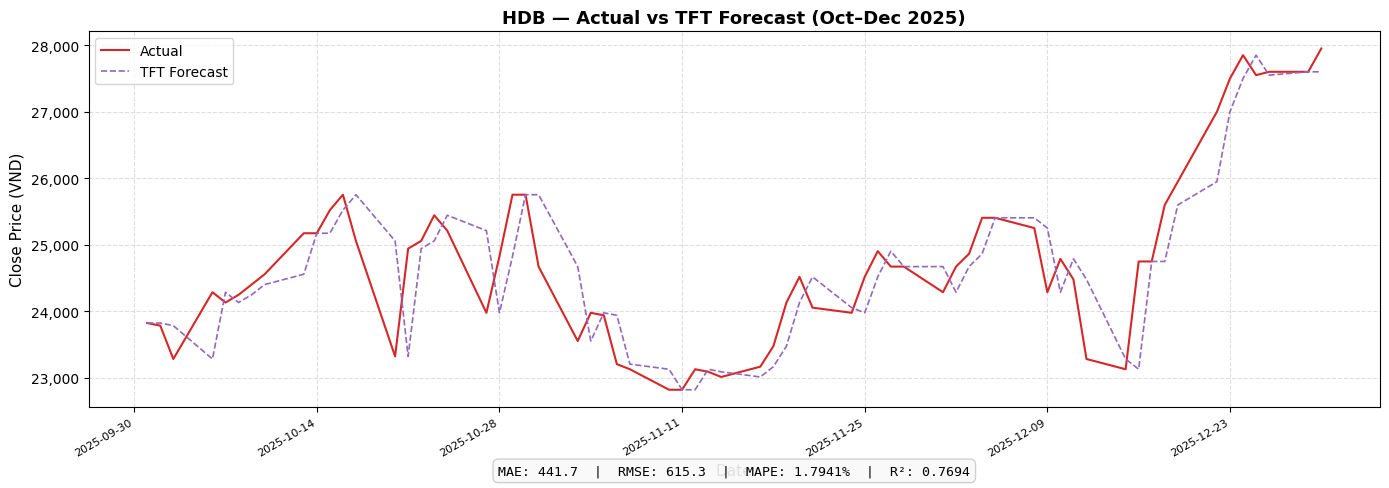

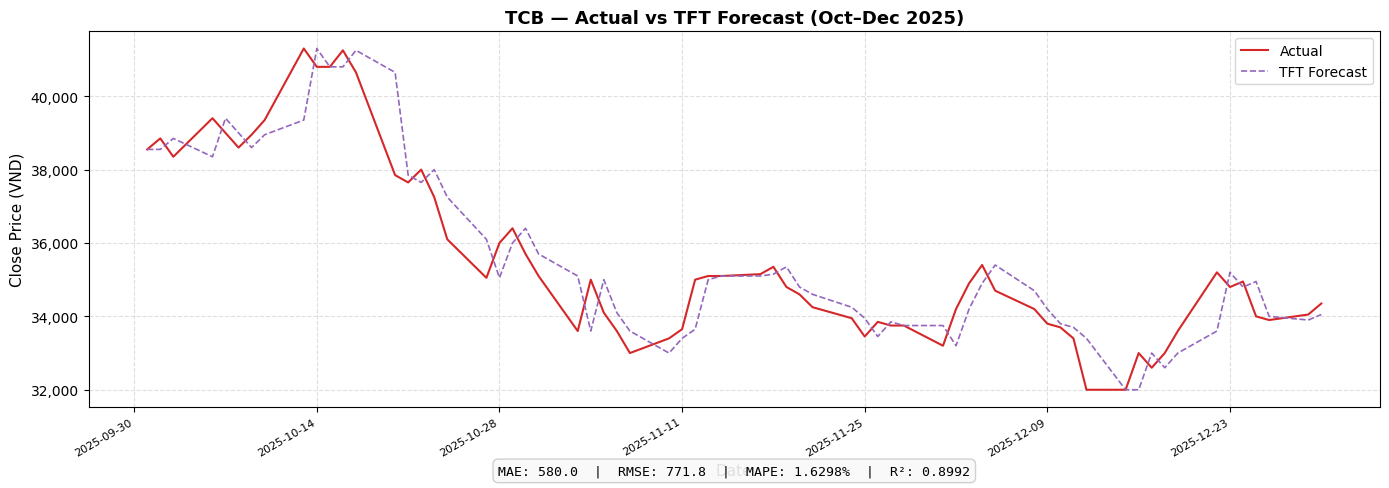

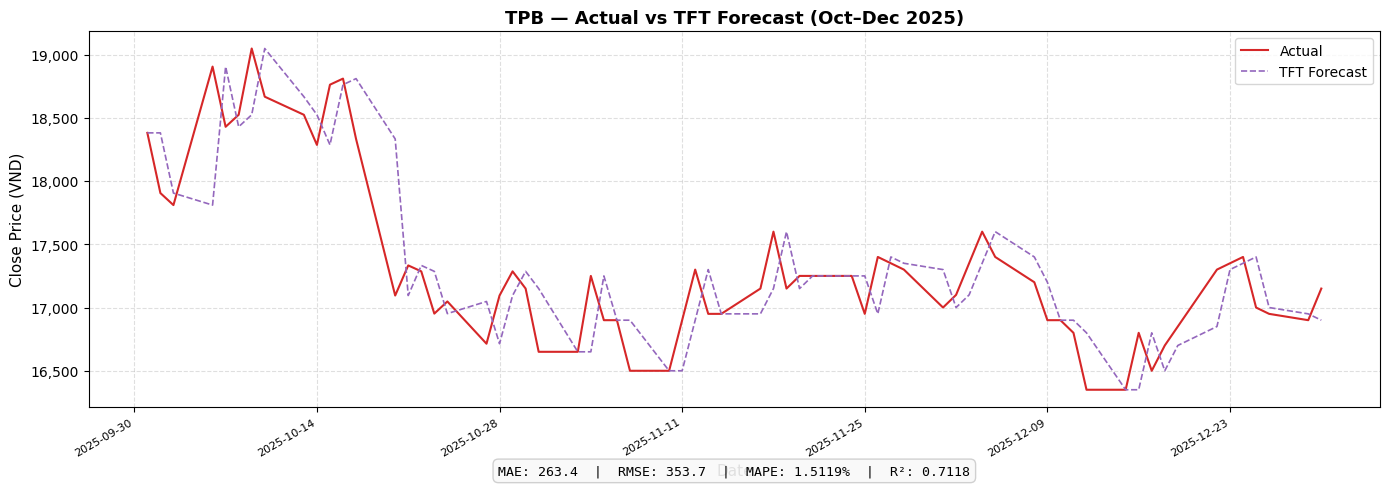

In [39]:
# ── CELL 9: FORECAST PLOTS ────────────────────────────────────────────────────
for ticker in TICKERS:
    if ticker not in tft_preds_direct:
        continue
    _, test   = stocks[ticker]
    test_idx  = pd.to_datetime(test.index[:len(tft_preds_direct[ticker])])
    test_vals = tft_actuals_direct[ticker]
    pred_vals = tft_preds_direct[ticker]
    row       = tft_metrics_df[tft_metrics_df['Model']==f'{ticker} — TFT'].iloc[0]

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(test_idx, test_vals, color='#d62728', linewidth=1.5, label='Actual')
    ax.plot(test_idx, pred_vals, color='#9467bd', linewidth=1.2,
            linestyle='--', label='TFT Forecast')
    ax.set_title(f'{ticker} — Actual vs TFT Forecast (Oct–Dec 2025)',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Date', fontsize=11)
    ax.set_ylabel('Close Price (VND)', fontsize=11)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right', fontsize=8)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    ax.legend(fontsize=10)
    ax.grid(linestyle='--', alpha=0.4)
    ax.annotate(
        f"MAE: {row['MAE']:,.1f}  |  RMSE: {row['RMSE']:,.1f}  |  "
        f"MAPE: {row['MAPE(%)']:.4f}%  |  R²: {row['R2']:.4f}",
        xy=(0.5, -0.18), xycoords='axes fraction',
        ha='center', fontsize=9.5, fontfamily='monospace',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#f9f9f9',
                  edgecolor='#cccccc', alpha=0.9)
    )
    plt.tight_layout()
    plt.show()